# RL Hyperparameter Tuning Analysis

Visualizes Stage 1 Bayesian Optimization / screening and Stage 2 robust validation. Switch `USE_HPC` in the configuration cell when final HPC outputs are ready.

In [33]:
from pathlib import Path
import json, math, warnings
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    pass
sns.set_context("notebook")
pd.set_option("display.max_columns", 100)

In [34]:
USE_HPC = True
TUNING_ROOT = Path("rl_tuning_hpc_gamma_high") if USE_HPC else Path("rl_tuning_hpc_100")
STAGE1_DIR = TUNING_ROOT / "stage1"
STAGE2_DIR = TUNING_ROOT / "stage2"
TOP_N = 5
try:
    from rl_tuning_common import PARAMETER_NAMES as PROJECT_PARAMETER_NAMES
except Exception:
    PROJECT_PARAMETER_NAMES = ["alpha", 
                               "gamma", 
                               "epsilon_decay", 
                               "epsilon_min", 
                               "risk_t1", 
                               "risk_window"]
PARAMETER_NAMES = list(PROJECT_PARAMETER_NAMES)

## Helpers

In [35]:
def warn(message: str) -> None:
    warnings.warn(message, stacklevel=2)
    print(f"WARNING: {message}")

def read_csv_if_exists(path: Path, **kwargs) -> pd.DataFrame:
    if not path.exists():
        warn(f"Missing CSV: {path}")
        return pd.DataFrame()
    try:
        return pd.read_csv(path, **kwargs)
    except Exception as exc:
        warn(f"Could not read {path}: {exc}")
        return pd.DataFrame()

def read_json_if_exists(path: Path) -> dict:
    if not path.exists():
        warn(f"Missing JSON: {path}")
        return {}
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except Exception as exc:
        warn(f"Could not read {path}: {exc}")
        return {}

def empty_plot_message(ax, message: str) -> None:
    ax.text(0.5, 0.5, message, ha="center", va="center", transform=ax.transAxes)
    ax.set_axis_off()

def valid_rows(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df.copy()
    out = df.copy()
    if "error" in out.columns:
        out = out[out["error"].fillna("").astype(str).str.len() == 0].copy()
    return out

def coerce_numeric(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    out = df.copy()
    for col in columns:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")
    return out

def stage2_dir(root: Path) -> Path:
    return root / "stage2" if (root / "stage2").exists() else root

def candidate_dir_from_row(row, root: Path) -> Path | None:
    data = dict(row)
    raw = data.get("candidate_dir")
    if raw is not None and not pd.isna(raw):
        path = Path(str(raw))
        if path.exists(): 
            return path
        fallback = stage2_dir(root) / path.name
        if fallback.exists(): 
            return fallback
    rank, trial = data.get("candidate_rank"), data.get("source_trial_index")
    if rank is not None and trial is not None and not pd.isna(rank) and not pd.isna(trial):
        path = stage2_dir(root) / f"candidate_rank_{int(rank):02d}_trial_{int(trial):03d}"
        if path.exists(): 
            return path
    return None

def load_stage1_trials(stage1_dir: Path = STAGE1_DIR) -> pd.DataFrame:
    df = read_csv_if_exists(stage1_dir / "stage1_trials.csv")
    if df.empty: return df
    nums = ["trial_index", 
            "objective_mean", 
            "objective_std", 
            "best_objective_so_far", 
            "total_reward_mean", 
            "late_order_fraction_mean", 
            "n_valid_replications", 
            *PARAMETER_NAMES]
    df = coerce_numeric(df, nums).sort_values("trial_index").reset_index(drop=True)
    if "best_objective_so_far" not in df.columns or df["best_objective_so_far"].isna().all():
        if "objective_mean" in df.columns: df["best_objective_so_far"] = df["objective_mean"].cummin()
    return df

def load_stage2_candidates(root: Path = TUNING_ROOT) -> pd.DataFrame:
    for path in [stage2_dir(root) / "stage2_candidates.csv", root / "stage2_candidates.csv"]:
        if path.exists():
            df = read_csv_if_exists(path)
            if not df.empty:
                nums = ["candidate_rank", 
                        "source_trial_index", 
                        "objective_mean", 
                        "objective_std", 
                        "total_reward_mean", 
                        "stage1_objective_mean", 
                        "stage1_total_reward_mean", 
                        "late_order_fraction_mean", 
                        "n_valid_replications", 
                        *PARAMETER_NAMES]
                return coerce_numeric(df, nums)
    rows=[]
    for cdir in sorted(stage2_dir(root).glob("candidate_rank_*_trial_*")):
        summary = read_json_if_exists(cdir / "candidate_summary.json")
        if summary:
            row={"candidate_rank":summary.get("candidate_rank"), 
                 "source_trial_index":summary.get("source_trial_index"), 
                 "objective_mean":summary.get("objective_mean"), 
                 "objective_std":summary.get("objective_std"), 
                 "total_reward_mean":summary.get("total_reward_mean"), 
                 "late_order_fraction_mean":summary.get("late_order_fraction_mean"), 
                 "n_valid_replications":summary.get("n_valid_replications"), 
                 "candidate_dir":str(cdir)}
            row.update(summary.get("parameters", {})); rows.append(row)
    if rows:
        return coerce_numeric(pd.DataFrame(rows), ["candidate_rank", 
                                                   "source_trial_index", 
                                                   "objective_mean", 
                                                   "objective_std", 
                                                   "total_reward_mean", 
                                                   "late_order_fraction_mean", 
                                                   "n_valid_replications", 
                                                   *PARAMETER_NAMES])
    warn(f"No completed Stage-2 candidate summary data found under {root}")
    return pd.DataFrame()

def load_stage2_evaluations(candidates: pd.DataFrame, root: Path = TUNING_ROOT) -> pd.DataFrame:
    frames=[]; rows = candidates.to_dict('records') if not candidates.empty else [{"candidate_dir":str(p)} for p in sorted(stage2_dir(root).glob("candidate_rank_*_trial_*"))]
    for row in rows:
        cdir = candidate_dir_from_row(row, root)
        if cdir is None: continue
        ev = read_csv_if_exists(cdir / "evaluation.csv")
        if ev.empty: continue
        for key in ["candidate_rank", "source_trial_index"]:
            if key in row and key not in ev.columns: ev[key] = row[key]
        ev["candidate_dir"] = str(cdir)
        if "candidate_rank" in ev.columns and ev["candidate_rank"].notna().any(): ev["candidate_label"] = "Rank " + str(int(ev["candidate_rank"].dropna().iloc[0]))
        else: ev["candidate_label"] = cdir.name
        frames.append(ev)
    if not frames:
        warn("No Stage-2 evaluation.csv files found for candidate distributions.")
        return pd.DataFrame()
    return coerce_numeric(valid_rows(pd.concat(frames, ignore_index=True, sort=False)), ["total_reward", 
                                                                                         "late_order_fraction", 
                                                                                         "time_in_system_mean", 
                                                                                         "wip_mean", "n_orders_late", 
                                                                                         "candidate_rank", 
                                                                                         "replication"])

## Load Tuning Data

In [36]:
stage1_config = read_json_if_exists(STAGE1_DIR / "stage1_config.json")
stage2_config = read_json_if_exists(STAGE2_DIR / "stage2_config.json")
stage1_trials = load_stage1_trials(STAGE1_DIR)
stage2_candidates = load_stage2_candidates(TUNING_ROOT)
stage2_evaluations = load_stage2_evaluations(stage2_candidates, TUNING_ROOT)
display(pd.DataFrame([
    {"source":"stage1_trials", "path":STAGE1_DIR / "stage1_trials.csv", "rows":len(stage1_trials)},
    {"source":"stage2_candidates", "path":STAGE2_DIR / "stage2_candidates.csv", "rows":len(stage2_candidates)},
    {"source":"stage2_evaluations", "path":STAGE2_DIR / "candidate_*/evaluation.csv", "rows":len(stage2_evaluations)},
]))
if stage1_config: display(pd.DataFrame([stage1_config]).T.rename(columns={0:"stage1_config"}).head(20))
if stage2_config: display(pd.DataFrame([stage2_config]).T.rename(columns={0:"stage2_config"}).head(20))

C:\Users\fabia\AppData\Local\Temp\ipykernel_13416\2024458506.py:17: UserWarning: Missing JSON: rl_tuning_hpc_gamma_high\stage2\stage2_config.json
  warn(f"Missing JSON: {path}")


,source,path,rows
0,stage1_trials,rl_tuning_hpc_gamma_high\stage1\stage1_trials.csv,100
1,stage2_candidates,rl_tuning_hpc_gamma_high\stage2\stage2_candida...,10
2,stage2_evaluations,rl_tuning_hpc_gamma_high\stage2\candidate_*\ev...,300


,stage1_config
stage,stage1_bo
n_trials,100
training_episodes,1000
eval_replications,10
bo_random_seed,24680
single_trial_script,/cfs/earth/scratch/freyfab2/BA/BA-Simulation-O...
run_duration,1440
rate_multiplier,0.9
base_seed,12345
seed_step,1000


## Stage 1: Best Objective So Far

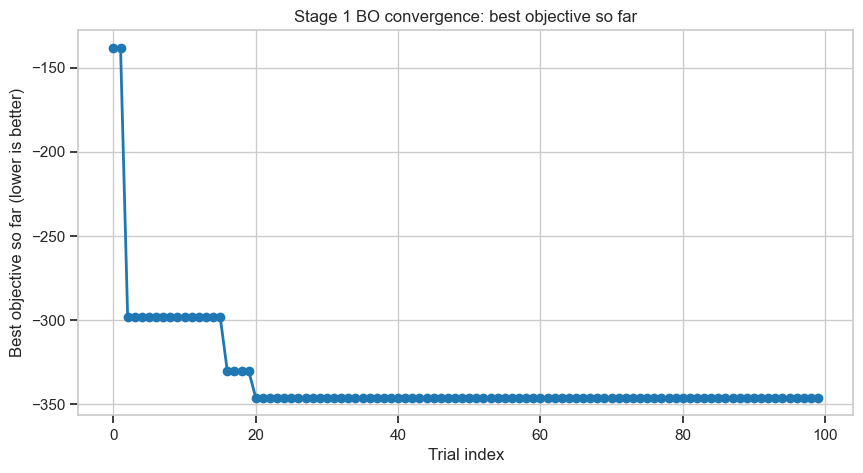

In [37]:
fig, ax = plt.subplots(figsize=(10,5))
if stage1_trials.empty or not {"trial_index", "best_objective_so_far"}.issubset(stage1_trials.columns): 
    empty_plot_message(ax, "No Stage-1 convergence data available.")
else:
    ax.plot(stage1_trials["trial_index"], stage1_trials["best_objective_so_far"], marker="o", linewidth=2)
    ax.set_title("Stage 1 BO convergence: best objective so far"); 
    ax.set_xlabel("Trial index"); 
    ax.set_ylabel("Best objective so far (lower is better)")
plt.show()

## Stage 1: Objective per Trial

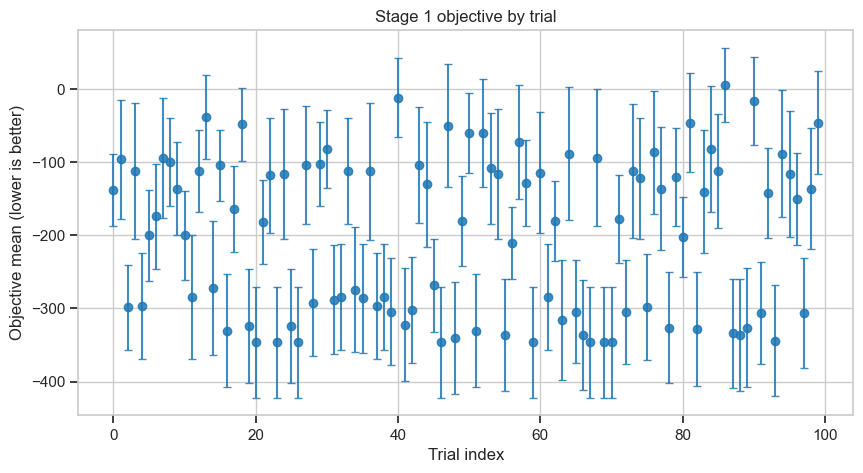

In [38]:
fig, ax = plt.subplots(figsize=(10,5))
if stage1_trials.empty or not {"trial_index", "objective_mean"}.issubset(stage1_trials.columns): 
    empty_plot_message(ax, "No Stage-1 objective data available.")
else:
    yerr = None
    if {"objective_std", "n_valid_replications"}.issubset(stage1_trials.columns): yerr = stage1_trials["objective_std"] / np.sqrt(stage1_trials["n_valid_replications"].clip(lower=1))
    ax.errorbar(stage1_trials["trial_index"], 
                stage1_trials["objective_mean"], 
                yerr=yerr, fmt="o", capsize=3, alpha=0.85)
    ax.set_title("Stage 1 objective by trial"); 
    ax.set_xlabel("Trial index"); 
    ax.set_ylabel("Objective mean (lower is better)")
plt.show()

## Hyperparameters vs. Objective

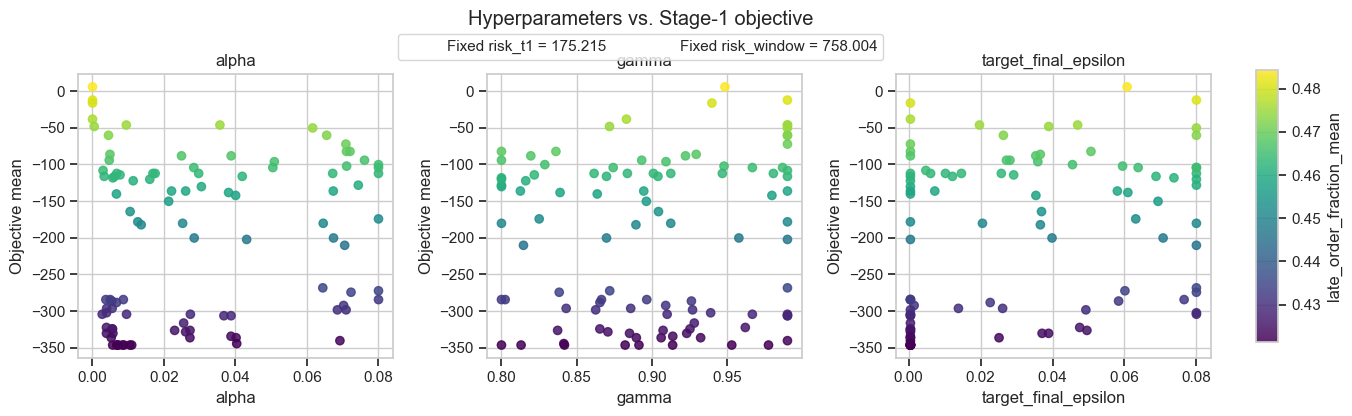

In [39]:
OPTIMIZED_PARAMETER_NAMES = list(
    stage1_config.get("parameter_names")
    or stage1_config.get("parameter_bounds", {}).keys()
)
DISPLAY_PARAMETER_NAMES = list(
    (
        stage1_config.get("all_parameter_bounds")
        or stage1_config.get("parameter_bounds", {})
    ).keys()
)
available_params = [p for p in OPTIMIZED_PARAMETER_NAMES if p in stage1_trials.columns]

fixed_risk = stage1_config.get("fixed_risk", {}) if stage1_config.get("use_fixed_risk") is True else {}
fixed_parameter_names = [
    p for p in DISPLAY_PARAMETER_NAMES
    if p not in OPTIMIZED_PARAMETER_NAMES and p in fixed_risk
]
if not available_params or stage1_trials.empty or "objective_mean" not in stage1_trials.columns:
    fig, ax = plt.subplots(figsize=(8,4)); empty_plot_message(ax, "No hyperparameter/objective data available."); plt.show()
else:
    n_cols=3; n_rows=math.ceil(len(available_params)/n_cols); fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols,4*n_rows), squeeze=False)
    cvals = stage1_trials["late_order_fraction_mean"] if "late_order_fraction_mean" in stage1_trials.columns else None; sc=None
    for ax, p in zip(axes.ravel(), available_params):
        if cvals is not None and cvals.notna().any(): sc = ax.scatter(stage1_trials[p], stage1_trials["objective_mean"], c=cvals, cmap="viridis", alpha=0.85)
        else: ax.scatter(stage1_trials[p], stage1_trials["objective_mean"], alpha=0.85)
        ax.set_title(p); ax.set_xlabel(p); ax.set_ylabel("Objective mean")
    for ax in axes.ravel()[len(available_params):]: ax.set_axis_off()
    fixed_handles = [
        Line2D([], [], linestyle="none", label=f"Fixed {p} = {fixed_risk[p]:g}")
        for p in fixed_parameter_names
    ]
    fig.suptitle("Hyperparameters vs. Stage-1 objective", y=0.98)
    if fixed_handles:
        fig.legend(handles=fixed_handles, loc="upper center", bbox_to_anchor=(0.5, 0.94), ncol=len(fixed_handles), frameon=True)
    fig.subplots_adjust(right=0.88, top=0.82 if fixed_handles else 0.88, wspace=0.3, hspace=0.35)
    if sc is not None:
        colorbar_ax = fig.add_axes([0.91, 0.15, 0.015, 0.68])
        fig.colorbar(sc, cax=colorbar_ax, label="late_order_fraction_mean")
    plt.show()

## Top Parameter Configurations

,trial_index,alpha,gamma,target_final_epsilon,objective_mean,total_reward_mean,late_order_fraction_mean,objective_std
20,20,0.005741,0.813035,0.0005,-346.2,346.2,0.421335,239.837352
26,26,0.007331,0.841861,0.0005,-346.2,346.2,0.421335,239.837352
23,23,0.006963,0.891348,0.0005,-346.2,346.2,0.421335,239.837352
46,46,0.006916,0.800000,0.0005,-346.2,346.2,0.421335,239.837352
59,59,0.008466,0.882166,0.0005,-346.2,346.2,0.421335,239.837352


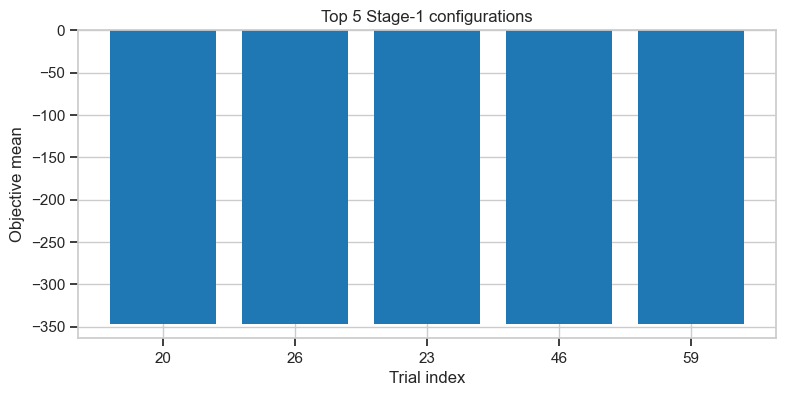

In [40]:
if stage1_trials.empty: print("No Stage-1 trials available.")
else:
    cols = ["trial_index", *available_params, "objective_mean", "total_reward_mean", "late_order_fraction_mean", "objective_std"]
    top_configs = stage1_trials.sort_values("objective_mean").head(min(TOP_N, len(stage1_trials)))[[c for c in cols if c in stage1_trials.columns]]
    display(top_configs)
    fig, ax = plt.subplots(figsize=(9,4))
    ax.bar(top_configs["trial_index"].astype(str), top_configs["objective_mean"], color="tab:blue")
    ax.set_title(f"Top {len(top_configs)} Stage-1 configurations"); ax.set_xlabel("Trial index"); ax.set_ylabel("Objective mean"); plt.show()

## Stage 1 vs. Stage 2

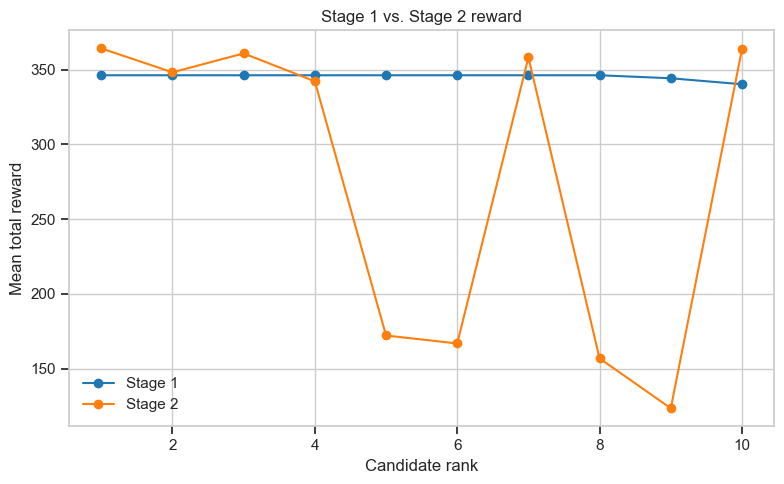

,candidate_rank,source_trial_index,alpha,gamma,target_final_epsilon,risk_t1,risk_window,epsilon_decay,epsilon_min,stage1_objective_mean,stage1_total_reward_mean,objective_mean,objective_std,total_reward_mean,total_reward_std,late_order_fraction_mean,n_valid_replications,best_training_reward,best_training_episode,best_training_seed,best_evaluation_reward,best_evaluation_replication,best_evaluation_seed,q_table_size,candidate_dir,q_table_path
0,1,20,0.005741,0.813035,0.0005,175.214912,758.004,0.99924,0.0005,-346.2,346.2,-364.166667,312.332392,364.166667,312.332392,0.419359,30,1590.0,3549,3761345,1243.0,26,338345,25,/cfs/earth/scratch/freyfab2/BA/BA-Simulation-O...,/cfs/earth/scratch/freyfab2/BA/BA-Simulation-O...
1,10,48,0.069221,0.990000,0.0005,175.214912,758.004,0.99924,0.0005,-340.2,340.2,-363.500000,319.740601,363.500000,319.740601,0.419551,30,1367.0,1707,1919345,1203.0,26,338345,25,/cfs/earth/scratch/freyfab2/BA/BA-Simulation-O...,/cfs/earth/scratch/freyfab2/BA/BA-Simulation-O...
2,3,23,0.006963,0.891348,0.0005,175.214912,758.004,0.99924,0.0005,-346.2,346.2,-360.833333,315.538629,360.833333,315.538629,0.419971,30,1387.0,1707,1919345,1243.0,26,338345,25,/cfs/earth/scratch/freyfab2/BA/BA-Simulation-O...,/cfs/earth/scratch/freyfab2/BA/BA-Simulation-O...
3,7,69,0.010516,0.977410,0.0005,175.214912,758.004,0.99924,0.0005,-346.2,346.2,-358.166667,316.416038,358.166667,316.416038,0.420416,30,1466.0,7830,8042345,1203.0,26,338345,25,/cfs/earth/scratch/freyfab2/BA/BA-Simulation-O...,/cfs/earth/scratch/freyfab2/BA/BA-Simulation-O...
4,2,26,0.007331,0.841861,0.0005,175.214912,758.004,0.99924,0.0005,-346.2,346.2,-348.166667,331.874206,348.166667,331.874206,0.422325,30,1590.0,3549,3761345,1203.0,26,338345,25,/cfs/earth/scratch/freyfab2/BA/BA-Simulation-O...,/cfs/earth/scratch/freyfab2/BA/BA-Simulation-O...
5,4,46,0.006916,0.800000,0.0005,175.214912,758.004,0.99924,0.0005,-346.2,346.2,-342.166667,320.349710,342.166667,320.349710,0.423300,30,1570.0,3549,3761345,1203.0,26,338345,26,/cfs/earth/scratch/freyfab2/BA/BA-Simulation-O...,/cfs/earth/scratch/freyfab2/BA/BA-Simulation-O...
6,5,59,0.008466,0.882166,0.0005,175.214912,758.004,0.99924,0.0005,-346.2,346.2,-172.166667,317.292108,172.166667,317.292108,0.453577,30,1426.0,7830,8042345,983.0,26,338345,26,/cfs/earth/scratch/freyfab2/BA/BA-Simulation-O...,/cfs/earth/scratch/freyfab2/BA/BA-Simulation-O...
7,6,70,0.011049,0.913725,0.0005,175.214912,758.004,0.99924,0.0005,-346.2,346.2,-166.833333,321.328823,166.833333,321.328823,0.454527,30,1446.0,7830,8042345,963.0,26,338345,25,/cfs/earth/scratch/freyfab2/BA/BA-Simulation-O...,/cfs/earth/scratch/freyfab2/BA/BA-Simulation-O...
8,8,67,0.008900,0.952997,0.0005,175.214912,758.004,0.99924,0.0005,-346.2,346.2,-156.833333,326.837203,156.833333,326.837203,0.456387,30,1547.0,1707,1919345,903.0,26,338345,25,/cfs/earth/scratch/freyfab2/BA/BA-Simulation-O...,/cfs/earth/scratch/freyfab2/BA/BA-Simulation-O...
9,9,93,0.040384,0.841424,0.0005,175.214912,758.004,0.99924,0.0005,-344.2,344.2,-123.500000,302.204972,123.500000,302.204972,0.462208,30,1466.0,7830,8042345,763.0,26,338345,27,/cfs/earth/scratch/freyfab2/BA/BA-Simulation-O...,/cfs/earth/scratch/freyfab2/BA/BA-Simulation-O...


In [41]:
fig, ax = plt.subplots(figsize=(8,5))
if stage2_candidates.empty:
    empty_plot_message(ax, "No Stage-2 candidate summary available.")
else:
    data = stage2_candidates.copy().sort_values("candidate_rank") if "candidate_rank" in stage2_candidates.columns else stage2_candidates.copy()
    x = data["candidate_rank"] if "candidate_rank" in data.columns else np.arange(1, len(data)+1)
    plotted=False
    if "stage1_total_reward_mean" in data.columns and data["stage1_total_reward_mean"].notna().any(): 
        ax.plot(x, data["stage1_total_reward_mean"], marker="o", label="Stage 1"); 
        plotted=True
    if "total_reward_mean" in data.columns and data["total_reward_mean"].notna().any(): 
        ax.plot(x, data["total_reward_mean"], marker="o", label="Stage 2"); 
        plotted=True
    if plotted: 
        ax.set_title("Stage 1 vs. Stage 2 reward"); ax.set_xlabel("Candidate rank"); 
        ax.set_ylabel("Mean total reward"); ax.legend()
    else: empty_plot_message(ax, "No mean total reward comparison available.")
plt.tight_layout(); plt.show(); display(stage2_candidates)

## Stage-2 Replication KPI Distributions

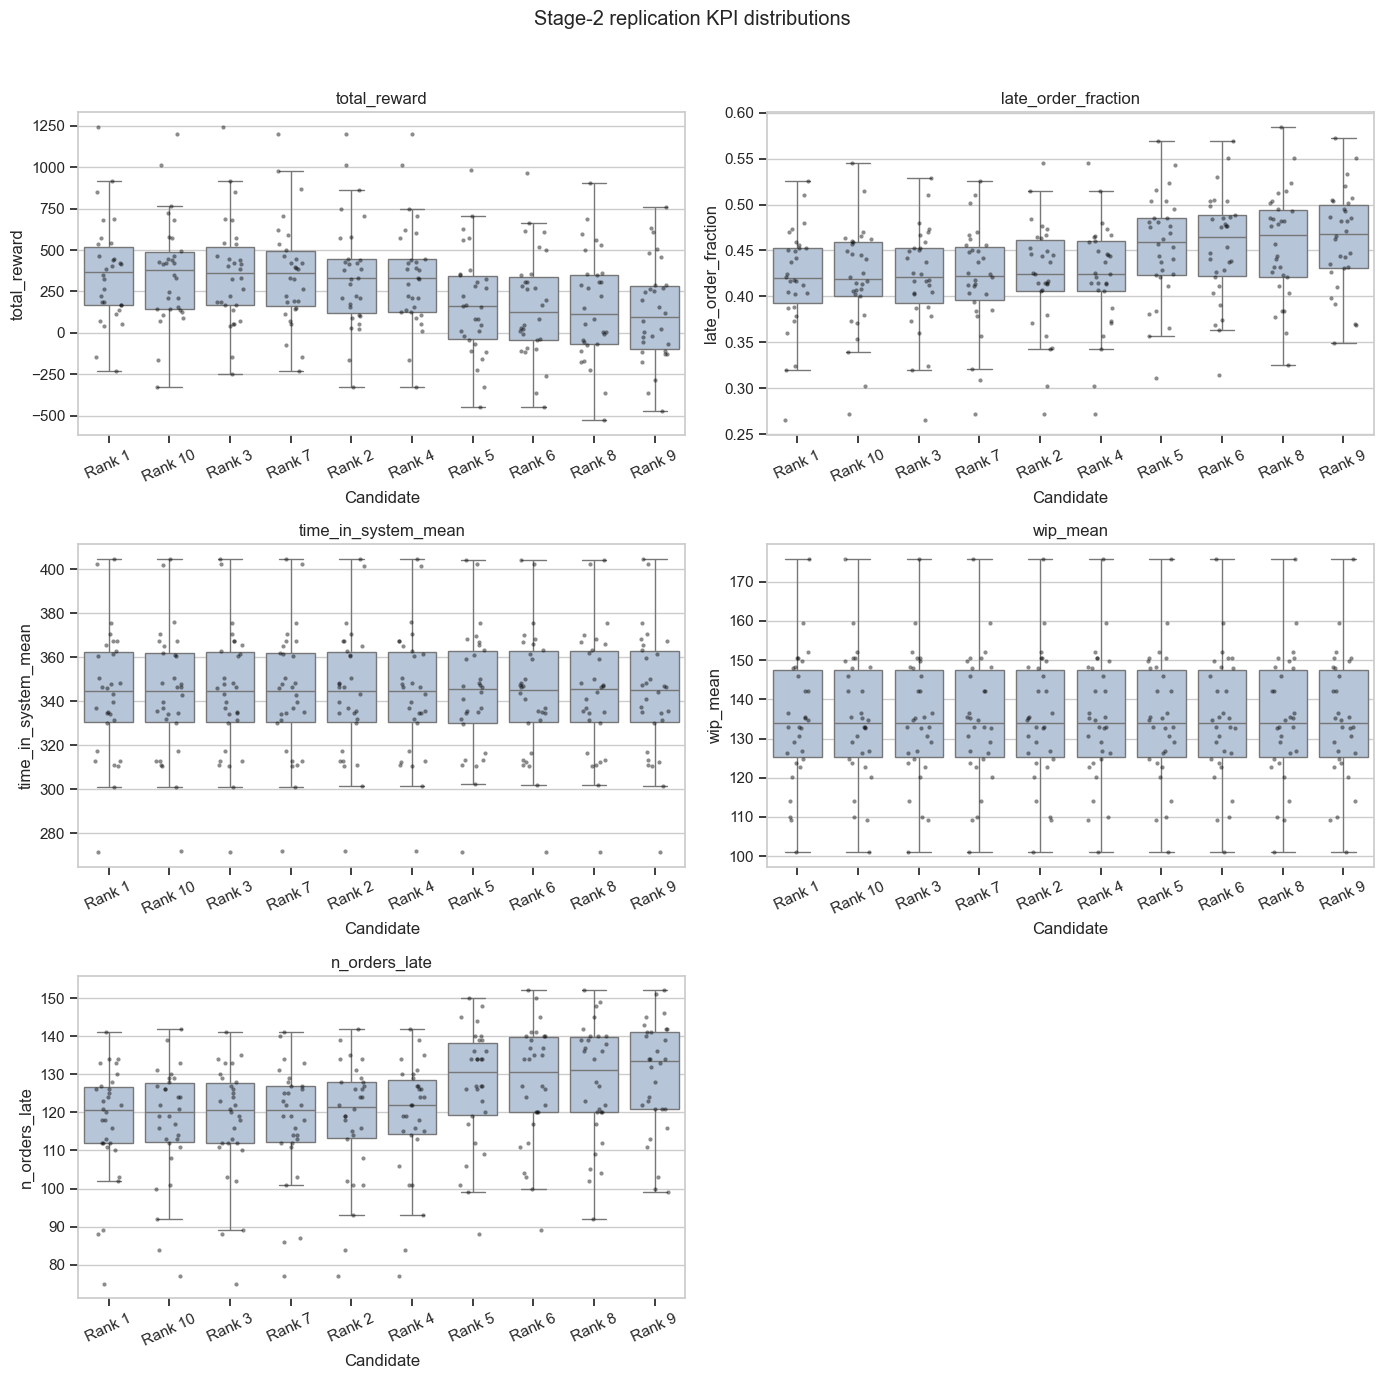

In [42]:
metrics = [m for m in ["total_reward", "late_order_fraction", "time_in_system_mean", "wip_mean", "n_orders_late"] if m in stage2_evaluations.columns]
if stage2_evaluations.empty or not metrics:
    fig, ax = plt.subplots(figsize=(8,4)); empty_plot_message(ax, "No Stage-2 replication KPI distributions available."); plt.show()
else:
    n_cols=2; n_rows=math.ceil(len(metrics)/n_cols); fig, axes = plt.subplots(n_rows,n_cols,figsize=(7*n_cols,4.5*n_rows), squeeze=False)
    available_labels = set(stage2_evaluations["candidate_label"].dropna().unique())
    if not stage2_candidates.empty and {"candidate_rank", "objective_mean"}.issubset(stage2_candidates.columns):
        stage2_order = (
            stage2_candidates.dropna(subset=["candidate_rank", "objective_mean"])
            .sort_values(["objective_mean", "candidate_rank"], ascending=[True, True])["candidate_rank"]
            .astype(int)
            .map(lambda rank: f"Rank {rank}")
            .tolist()
        )
        order = [label for label in stage2_order if label in available_labels]
    else:
        order = (
            stage2_evaluations.dropna(subset=["candidate_rank", "candidate_label"])
            .sort_values("candidate_rank")["candidate_label"]
            .drop_duplicates()
            .tolist()
        )
    for ax, metric in zip(axes.ravel(), metrics):
        sns.boxplot(data=stage2_evaluations, x="candidate_label", y=metric, order=order, ax=ax, color="lightsteelblue", showfliers=False)
        sns.stripplot(data=stage2_evaluations, x="candidate_label", y=metric, order=order, ax=ax, color="black", alpha=0.45, size=3, jitter=0.22)
        ax.set_title(metric); ax.set_xlabel("Candidate"); ax.tick_params(axis="x", rotation=25)
    for ax in axes.ravel()[len(metrics):]: ax.set_axis_off()
    fig.suptitle("Stage-2 replication KPI distributions", y=1.02); plt.tight_layout(); plt.show()